# Fault-tolerant Bell-state preparation

A small Stim circuit describes the desired logical CSS state. Each Stim qubit is one encoded block of the selected `[[n, 1, d]]` CSS code.

In [12]:
import numpy as np
import stim

from spidercss.css_state import prepare_css_state
from spidercss.utils import count_operations, load_qecc


bell_state = stim.Circuit("""
    M 0
    MX 1
    CX 1 0
""")
ts = stim.TableauSimulator()
ts.do(bell_state)
print(ts.canonical_stabilizers())

[stim.PauliString("+XX"), stim.PauliString("+ZZ")]


Here `M` and `MX` are declarative preparation instructions for logical `|0>` and `|+>`; their measurement results are not copied into the compiled circuit. `R` and `RX` are equivalent spellings. The logical `CX` becomes a transversal CNOT between the encoded blocks. Other gates are rejected.

In [2]:
def prepare_and_verify_bell_state(code, *, method="FAO", shots=256):
    circuit = prepare_css_state(
        bell_state,
        code,
        method=method,
        max_basis_tries=1_000,
    )

    _, h_x, h_z, l_x, l_z, _ = load_qecc(code, method)
    n = h_x.shape[1]

    # Z samples check each block's Z stabilizers and the logical ZZ Bell stabilizer.
    # X samples similarly check the X stabilizers and logical XX.
    for basis, stabilizers, logical_operator in (
        ("Z", h_z, l_z),
        ("X", h_x, l_x),
    ):
        measured = circuit.copy()
        measured.append("M" + basis, range(2 * n))
        samples = measured.compile_sampler().sample(shots)[:, -2 * n:]
        samples = samples.reshape(shots, 2, n)

        assert not np.any(samples @ stabilizers.T % 2)
        logical_values = samples @ logical_operator.T % 2
        assert not np.any(logical_values[:, 0] ^ logical_values[:, 1])

    num_cnots, _ = count_operations(circuit)
    print(
        f"{code}: {2 * n} data qubits, "
        f"{circuit.num_qubits - 2 * n} preparation ancillas, "
        f"{num_cnots} CNOTs; Bell checks passed"
    )
    return circuit

## `[[7, 1, 3]]` code

7_1_3: 14 data qubits, 6 preparation ancillas, 37 CNOTs; Bell checks passed


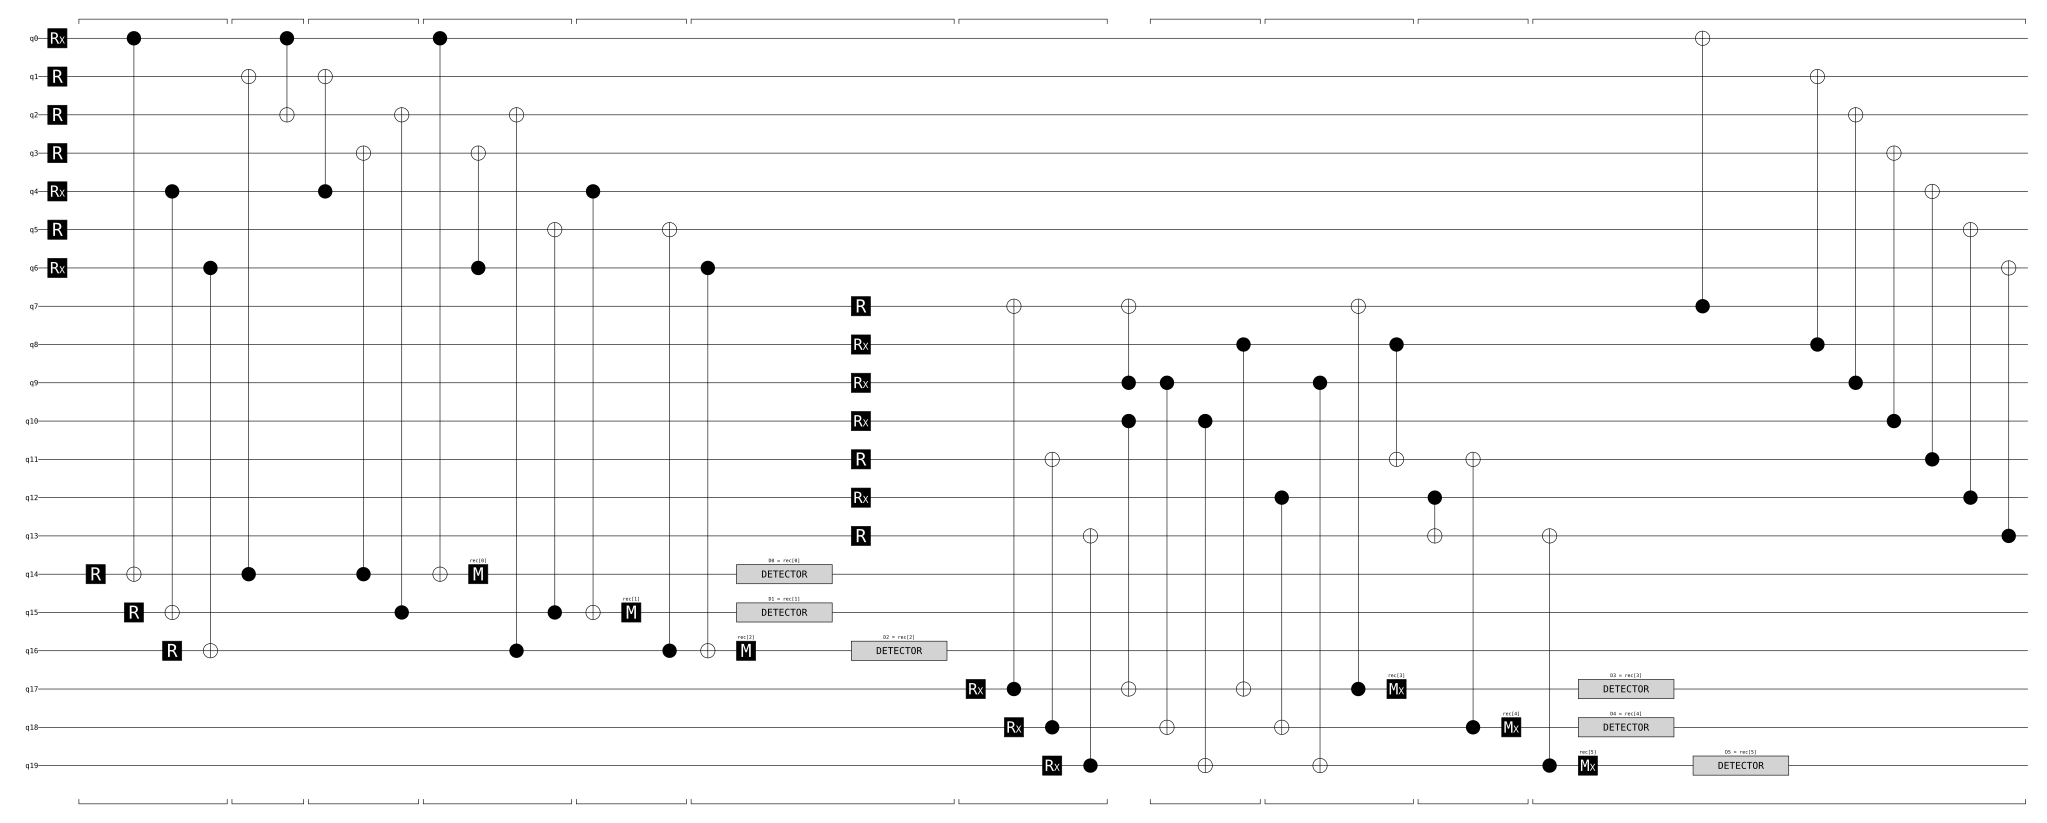

In [4]:
bell_7_1_3 = prepare_and_verify_bell_state("7_1_3")
bell_7_1_3.diagram('timeline-svg')

## `[[17, 1, 5]]` code

17_1_5: 34 data qubits, 42 preparation ancillas, 165 CNOTs; Bell checks passed


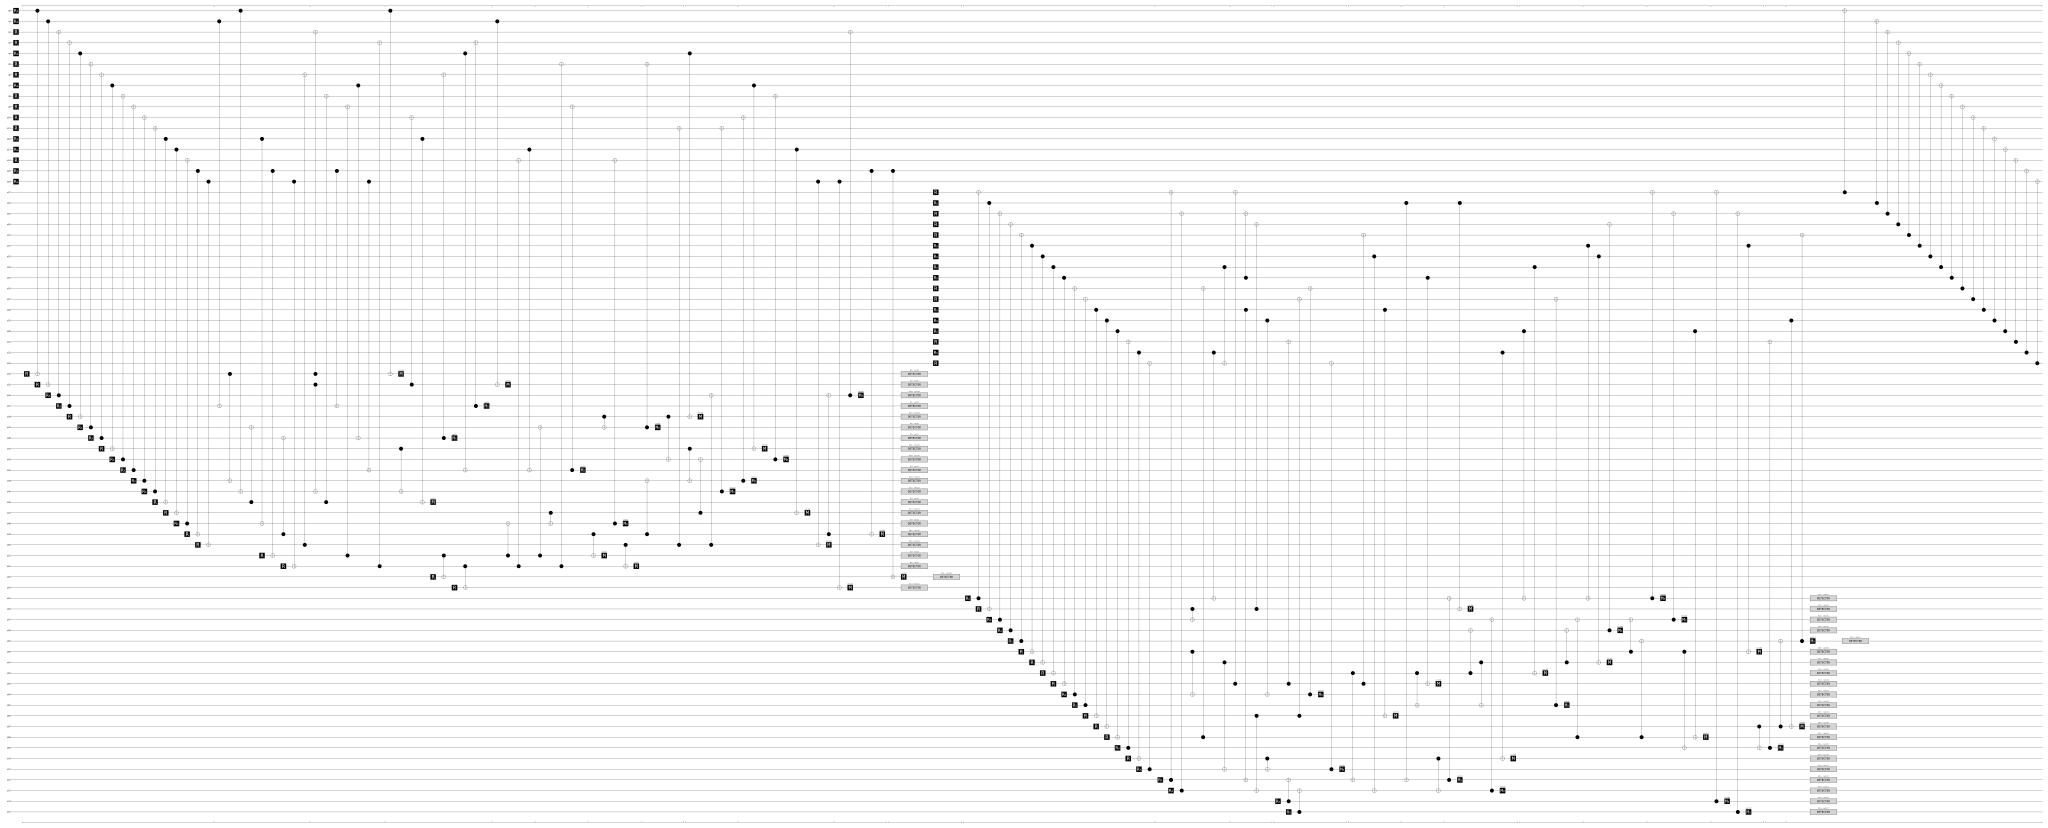

In [5]:
bell_17_1_5 = prepare_and_verify_bell_state("17_1_5")
bell_17_1_5.diagram('timeline-svg')